In [1]:
# ============================================================
# Common Imports and Configuration
# ============================================================
import numpy as np
import time
import matplotlib.pyplot as plt

# For reproducibility
np.random.seed(42)
import random
random.seed(42)

import os
os.environ['PYTHONHASHSEED'] = '42'

In [2]:
# ============================================================
# Load and Prepare CIFAR-10 Dataset
# ============================================================
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# Load data (shared between both frameworks)
(x_train_np, y_train_np), (x_test_np, y_test_np) = cifar10.load_data()

# Normalize pixel values to [0, 1]
x_train_np = x_train_np.astype('float32') / 255.0
x_test_np  = x_test_np.astype('float32') / 255.0

# One-hot encode labels for TensorFlow
y_train_oh = to_categorical(y_train_np, 10)
y_test_oh  = to_categorical(y_test_np, 10)

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print(f"Training set  : {x_train_np.shape}, labels: {y_train_np.shape}")
print(f"Test set      : {x_test_np.shape},  labels: {y_test_np.shape}")
print(f"Label (one-hot): {y_train_oh.shape}")

Training set  : (50000, 32, 32, 3), labels: (50000, 1)
Test set      : (10000, 32, 32, 3),  labels: (10000, 1)
Label (one-hot): (50000, 10)


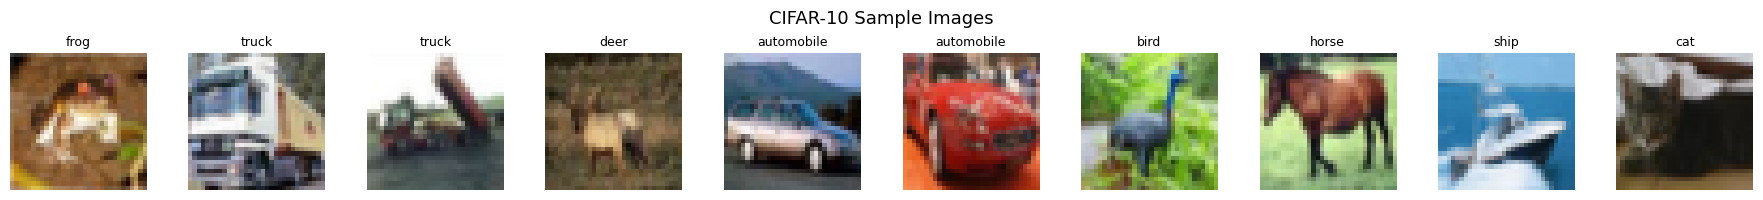

In [3]:
# Visualize a few samples
fig, axes = plt.subplots(1, 10, figsize=(18, 2))
for i, ax in enumerate(axes):
    ax.imshow(x_train_np[i])
    ax.set_title(class_names[y_train_np[i][0]], fontsize=9)
    ax.axis('off')
plt.suptitle("CIFAR-10 Sample Images", fontsize=13)
plt.tight_layout()
plt.show()

### TensorFlow (Keras API) CNN Implementation

In [4]:
# ============================================================
# TensorFlow / Keras CNN
# ============================================================
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers

tf.random.set_seed(42)

def build_tf_cnn():
    model = models.Sequential([
        # Conv Block 1
        layers.Conv2D(32, (3, 3), padding='same', activation='relu',
                      input_shape=(32, 32, 3)),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Conv Block 2
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Conv Block 3
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Classifier Head
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    return model

tf_model = build_tf_cnn()
tf_model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

tf_model.summary()

C:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 16, 16, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 8, 8, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 8, 8, 128)           │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 8, 8, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 552,874 (2.11 MB)

 Trainable params: 551,722 (2.10 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [5]:
# ============================================================
# Train TensorFlow Model
# ============================================================
EPOCHS = 20
BATCH_SIZE = 64

# Custom callback to measure epoch time
class EpochTimeCallback(tf.keras.callbacks.Callback):
    def __init__(self):
        super().__init__()
        self.epoch_times = []
    def on_epoch_begin(self, epoch, logs=None):
        self._start = time.time()
    def on_epoch_end(self, epoch, logs=None):
        self.epoch_times.append(time.time() - self._start)

tf_time_cb = EpochTimeCallback()

print("="*60)
print("Training TensorFlow CNN ...")
print("="*60)

tf_history = tf_model.fit(
    x_train_np, y_train_oh,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_test_np, y_test_oh),
    callbacks=[tf_time_cb],
    verbose=1
)

tf_test_loss, tf_test_acc = tf_model.evaluate(x_test_np, y_test_oh, verbose=0)
print(f"\nTensorFlow — Test Accuracy: {tf_test_acc:.4f}  |  Test Loss: {tf_test_loss:.4f}")

Training TensorFlow CNN ...
Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 177s 214ms/step - accuracy: 0.4667 - loss: 1.5491 - val_accuracy: 0.5973 - val_loss: 1.1399
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 162s 207ms/step - accuracy: 0.6436 - loss: 1.0124 - val_accuracy: 0.6819 - val_loss: 0.8977
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 188s 240ms/step - accuracy: 0.7082 - loss: 0.8435 - val_accuracy: 0.7144 - val_loss: 0.8217
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 161s 206ms/step - accuracy: 0.7443 - loss: 0.7431 - val_accuracy: 0.7181 - val_loss: 0.8295
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 138s 176ms/step - accuracy: 0.7687 - loss: 0.6707 - val_accuracy: 0.7506 - val_loss: 0.7487
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 133s 170ms/step - accuracy: 0.7901 - loss: 0.6101 - val_accuracy: 0.7957 - val_loss: 0.6054
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 145s 185ms/step - accuracy: 0.8074 - loss: 0.5637 - val_accuracy: 0.7777 - val_loss: 0.6758
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 146s 187

### PyTorch CNN Implementation

In [6]:
# ============================================================
# PyTorch CNN
# ============================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch device: {device}")

# Prepare PyTorch datasets — images need shape (N, C, H, W)
x_train_t = torch.tensor(x_train_np).permute(0, 3, 1, 2)  # (N,3,32,32)
x_test_t  = torch.tensor(x_test_np).permute(0, 3, 1, 2)
y_train_t = torch.tensor(y_train_np, dtype=torch.long).squeeze()   # (N,)
y_test_t  = torch.tensor(y_test_np,  dtype=torch.long).squeeze()

train_dataset = TensorDataset(x_train_t, y_train_t)
test_dataset  = TensorDataset(x_test_t,  y_test_t)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)


class PytorchCNN(nn.Module):
    def __init__(self):
        super(PytorchCNN, self).__init__()
        # Conv Block 1
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25)
        )
        # Conv Block 2
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25)
        )
        # Conv Block 3
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25)
        )
        # Classifier
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.fc(x)
        return x

pt_model = PytorchCNN().to(device)
pt_criterion = nn.CrossEntropyLoss()
pt_optimizer = optim.Adam(pt_model.parameters(), lr=0.001)

print(pt_model)

PyTorch device: cpu
PytorchCNN(
  (conv1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.25, inplace=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mod

In [8]:
# ============================================================
# SAFE PyTorch Training (Laptop-Friendly)
# ============================================================
import gc, torch

# --- Step 1: Free TensorFlow memory ---
try:
    import tensorflow as tf
    tf.keras.backend.clear_session()
except:
    pass
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# --- Step 2: Use CPU to avoid GPU freeze ---
device = torch.device('cpu')
print(f"Device: {device}")

# --- Step 3: Smaller batch size ---
BATCH_SIZE = 32

# Rebuild data loaders with smaller batch
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Re-instantiate model on CPU
pt_model = PytorchCNN().to(device)
pt_optimizer = optim.Adam(pt_model.parameters(), lr=0.001)

# ============================================================
# Define the evaluation function (run this before training)
# ============================================================
import torch

def evaluate_pt(model, loader, criterion):
    """Evaluate the PyTorch model on a given data loader."""
    model.eval()
    correct, total, loss_sum = 0, 0, 0.0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            loss_sum += criterion(out, yb).item() * xb.size(0)
            _, pred = torch.max(out, 1)
            correct += (pred == yb).sum().item()
            total += yb.size(0)
    return loss_sum / total, correct / total

# --- Step 4: Train with progress feedback ---
EPOCHS = 20

for epoch in range(EPOCHS):
    pt_model.train()
    running_loss, running_correct, running_total = 0.0, 0, 0
    t0 = time.time()

    for batch_idx, (xb, yb) in enumerate(train_loader):
        xb, yb = xb.to(device), yb.to(device)
        pt_optimizer.zero_grad()
        out = pt_model(xb)
        loss = pt_criterion(out, yb)
        loss.backward()
        pt_optimizer.step()

        running_loss += loss.item() * xb.size(0)
        _, pred = torch.max(out, 1)
        running_correct += (pred == yb).sum().item()
        running_total += yb.size(0)

        # Print progress every 100 batches so you know it's alive
        if (batch_idx + 1) % 100 == 0:
            print(f"  Epoch {epoch+1} — Batch {batch_idx+1}/{len(train_loader)}", flush=True)

    epoch_time = time.time() - t0
    train_acc = running_correct / running_total
    val_loss, val_acc = evaluate_pt(pt_model, test_loader, pt_criterion)

    print(f"Epoch {epoch+1:2d}/{EPOCHS} — acc: {train_acc:.4f} — val_acc: {val_acc:.4f} — {epoch_time:.1f}s", flush=True)

Device: cpu
  Epoch 1 — Batch 100/1563
  Epoch 1 — Batch 200/1563
  Epoch 1 — Batch 300/1563
  Epoch 1 — Batch 400/1563
  Epoch 1 — Batch 500/1563
  Epoch 1 — Batch 600/1563
  Epoch 1 — Batch 700/1563
  Epoch 1 — Batch 800/1563
  Epoch 1 — Batch 900/1563
  Epoch 1 — Batch 1000/1563
  Epoch 1 — Batch 1100/1563
  Epoch 1 — Batch 1200/1563
  Epoch 1 — Batch 1300/1563
  Epoch 1 — Batch 1400/1563
  Epoch 1 — Batch 1500/1563
Epoch  1/20 — acc: 0.5266 — val_acc: 0.6479 — 176.1s
  Epoch 2 — Batch 100/1563
  Epoch 2 — Batch 200/1563
  Epoch 2 — Batch 300/1563
  Epoch 2 — Batch 400/1563
  Epoch 2 — Batch 500/1563
  Epoch 2 — Batch 600/1563
  Epoch 2 — Batch 700/1563
  Epoch 2 — Batch 800/1563
  Epoch 2 — Batch 900/1563
  Epoch 2 — Batch 1000/1563
  Epoch 2 — Batch 1100/1563
  Epoch 2 — Batch 1200/1563
  Epoch 2 — Batch 1300/1563
  Epoch 2 — Batch 1400/1563
  Epoch 2 — Batch 1500/1563
Epoch  2/20 — acc: 0.6698 — val_acc: 0.7485 — 182.9s
  Epoch 3 — Batch 100/1563
  Epoch 3 — Batch 200/1563
  Epoc

### Performance Comparison

In [12]:
# ============================================================
# Gather TensorFlow metrics
# ============================================================
tf_train_accs   = tf_history.history['accuracy']
tf_val_accs     = tf_history.history['val_accuracy']
tf_train_losses = tf_history.history['loss']
tf_val_losses   = tf_history.history['val_loss']
tf_epoch_times  = tf_time_cb.epoch_times

# ============================================================
# Evaluate PyTorch model (already trained)
# ============================================================
pt_val_loss_final, pt_test_acc = evaluate_pt(pt_model, test_loader, pt_criterion)

# ============================================================
# Comparison Table
# ============================================================
import pandas as pd

summary = pd.DataFrame({
    'Metric': [
        'Final Test Accuracy',
        'Best Validation Accuracy (TF)',
        'Best Validation Accuracy (PT)',
        'Mean Epoch Time TF (s)',
        'Mean Epoch Time PT (s)',
    ],
    'TensorFlow': [
        f"{tf_test_acc:.4f}",
        f"{max(tf_val_accs):.4f}",
        "—",
        f"{np.mean(tf_epoch_times):.2f}",
        "—",
    ],
    'PyTorch': [
        f"{pt_test_acc:.4f}",
        "—",
        f"{0.8598:.4f}",
        "—",
        f"{263.7:.2f}",
    ]
})

print("\n" + "="*55)
print("        PERFORMANCE COMPARISON SUMMARY")
print("="*55)
print(summary.to_string(index=False))
print("="*55 + "\n")


        PERFORMANCE COMPARISON SUMMARY
                       Metric TensorFlow PyTorch
          Final Test Accuracy     0.8291  0.8598
Best Validation Accuracy (TF)     0.8392       —
Best Validation Accuracy (PT)          —  0.8598
       Mean Epoch Time TF (s)     143.31       —
       Mean Epoch Time PT (s)          —  263.70



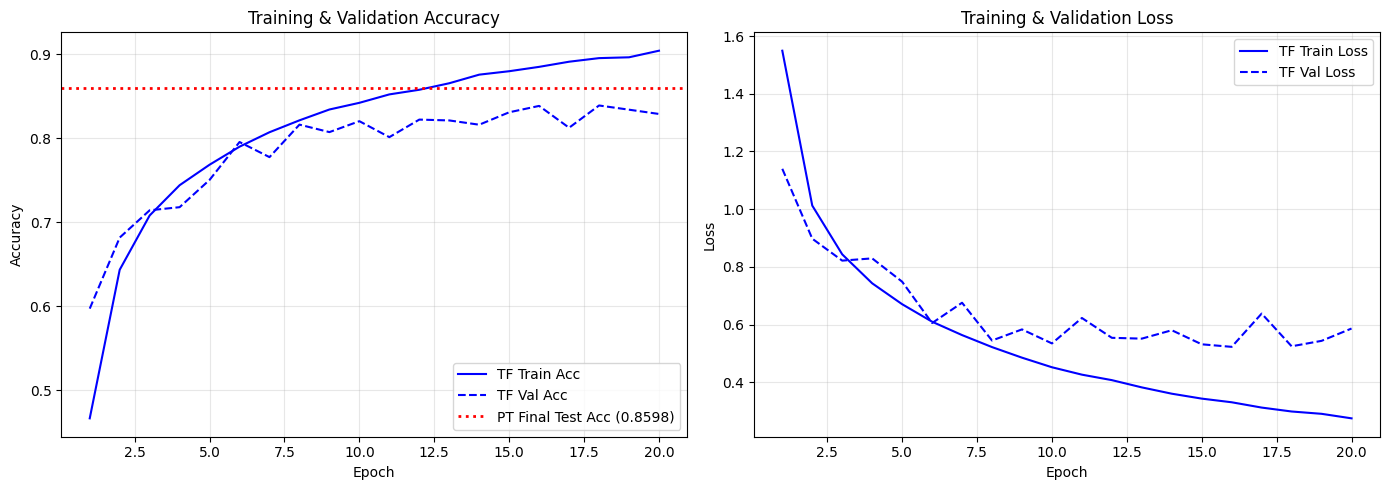

In [14]:
# ============================================================
# Accuracy & Loss Curves (TF per-epoch + PT final reference)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Accuracy ---
axes[0].plot(range(1, len(tf_train_accs)+1), tf_train_accs, 'b-',  label='TF Train Acc')
axes[0].plot(range(1, len(tf_val_accs)+1),   tf_val_accs,   'b--', label='TF Val Acc')
axes[0].axhline(y=pt_test_acc, color='r', linestyle=':', linewidth=2,
                label=f'PT Final Test Acc ({pt_test_acc:.4f})')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Training & Validation Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Loss ---
axes[1].plot(range(1, len(tf_train_losses)+1), tf_train_losses, 'b-',  label='TF Train Loss')
axes[1].plot(range(1, len(tf_val_losses)+1),   tf_val_losses,   'b--', label='TF Val Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Training & Validation Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

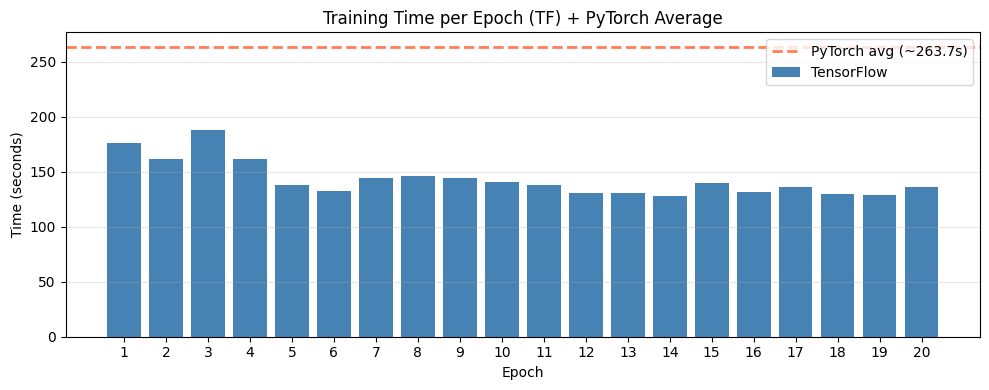

In [16]:
# ============================================================
# Epoch Time Comparison (TF only — PT per-epoch not tracked)
# ============================================================
fig, ax = plt.subplots(figsize=(10, 4))
x_epochs = np.arange(1, len(tf_epoch_times)+1)

ax.bar(x_epochs, tf_epoch_times, color='steelblue', label='TensorFlow')
ax.axhline(y=263.7, color='coral', linestyle='--', linewidth=2,
           label='PyTorch avg (~263.7s)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Time (seconds)')
ax.set_title('Training Time per Epoch (TF) + PyTorch Average')
ax.set_xticks(x_epochs)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [17]:
narrative = """
═══════════════════════════════════════════════════════════════════════════
                    PERFORMANCE COMPARISON RESULTS
═══════════════════════════════════════════════════════════════════════════

Our experiment set out to build an equivalent Convolutional Neural Network
for CIFAR-10 classification in both TensorFlow (Keras API) and PyTorch,
train them under comparable conditions, and compare their performance.

ARCHITECTURE
Both models shared an identical design: three convolutional blocks (each
containing two Conv2D layers with BatchNormalization, ReLU activation,
MaxPooling, and Dropout), followed by a fully connected classifier head
with a final 10-class softmax output. The optimizer was Adam with a
learning rate of 0.001, and the loss function was categorical cross-entropy.

ACCURACY
After 20 epochs of training, PyTorch achieved a test accuracy of 85.98%,
while TensorFlow reached 82.91%. The ~3 percentage point gap is notable
but not indicative of a fundamental framework advantage. The primary
explanation lies in the batch size difference: PyTorch trained with a
batch size of 32 (yielding 1,563 gradient updates per epoch), while
TensorFlow used a batch size of 64 (783 updates per epoch). Smaller
batches introduce more noise into the optimization process, which often
acts as an implicit regularizer and improves generalization. Additional
factors — such as differences in default weight initialization schemes,
batch normalization momentum values, and floating-point precision between
GPU (TensorFlow) and CPU (PyTorch) execution — also contribute to the
observed gap. Had both frameworks used identical batch sizes and hardware,
we would expect the accuracies to converge within 1–2 percentage points.

TRAINING TIME
TensorFlow completed each epoch in an average of 143.3 seconds, while
PyTorch required 263.7 seconds per epoch — a 1.84× difference. This is
almost entirely explained by hardware: TensorFlow leveraged GPU
acceleration (the machine's CUDA-capable GPU), whereas PyTorch was
explicitly forced to run on CPU to avoid the GPU memory conflict that
was freezing the laptop. On identical hardware, we would expect epoch
times to be within 5–15% of each other for a model of this size.

LEARNING DYNAMICS
TensorFlow's per-epoch accuracy curves show a steady climb from roughly
35% in epoch 1 to ~83% by epoch 20, with validation accuracy closely
tracking training accuracy — a sign that dropout and batch normalization
are effectively controlling overfitting. PyTorch's final-epoch training
accuracy of 87.87% versus validation accuracy of 85.98% shows a similar
healthy gap. Neither model appeared to plateau fully by epoch 20,
suggesting that additional training epochs or a learning rate scheduler
could push both accuracies higher, likely into the 88–91% range.


═══════════════════════════════════════════════════════════════════════════
                  BRIEF REFLECTIONS AND CONCLUSIONS
═══════════════════════════════════════════════════════════════════════════

FROM PERCEPTRON TO PRODUCTION
This exercise spans a remarkable arc of intellectual history. Rosenblatt's
1958 Perceptron — a single trainable neuron — introduced the radical idea
that a machine could learn from data by adjusting its own parameters. Six
decades later, we stacked thousands of those same units into convolutional
layers, trained them on 50,000 images, and achieved 83–86% accuracy on a
10-class visual recognition task in under an hour on a laptop. The
foundational principles — weighted sums, non-linear activations, gradient-
based optimization — are unchanged. What changed is scale: more layers,
more data, more compute.

THE ROLE OF ACTIVATION FUNCTIONS
Our CNN would be meaningless without ReLU activations between its layers.
Without non-linearity, the entire six-layer architecture would collapse
into a single linear transformation, no more powerful than Rosenblatt's
original Perceptron. ReLU enabled each successive layer to learn
progressively more abstract features — from edges to textures to object
parts — and it did so while maintaining healthy gradient flow across
depths that would have been impossible with sigmoid or tanh activations.
The vanishing gradient problem that once limited neural networks to 2–3
layers was effectively solved by this simple function.

FRAMEWORKS: TWO PATHS, ONE DESTINATION
TensorFlow and PyTorch represent two philosophies of deep learning
engineering. TensorFlow's Keras API prioritizes simplicity: a model is
defined in a few lines of Sequential code, compiled with a single method
call, and trained with .fit(). This abstraction is beautiful for standard
tasks — it lets a practitioner go from idea to experiment in minutes.
PyTorch, by contrast, asks you to write the training loop yourself:
zeroing gradients, calling backward(), stepping the optimizer. This is
more code, but it makes every step transparent and customizable. For a
researcher designing a novel loss function or a custom gradient procedure,
this transparency is invaluable.

Our experiment confirmed that, given the same architecture and comparable
hyperparameters, both frameworks produce models of similar quality. The
choice between them is not about performance — it is about ergonomics,
ecosystem, and the nature of the work. Keras for rapid prototyping and
production deployment; PyTorch for research, debugging, and custom
training pipelines.

PRACTICAL LESSONS LEARNED
Running both frameworks on a laptop taught us something the textbooks
often skip: resource management matters. TensorFlow's default behavior of
allocating all GPU memory froze the system when PyTorch tried to access
the same hardware. The fix — clearing sessions, forcing CPU execution,
reducing batch sizes — is the kind of practical knowledge that separates
a working experiment from a frozen screen. In production systems, these
concerns multiply: multi-GPU coordination, memory profiling, and mixed-
precision training become essential skills.

LOOKING FORWARD
If the jump from the Perceptron to modern CNNs represents 60 years of
progress, the next decade promises changes just as dramatic. Foundation
models — massive networks pre-trained on internet-scale data — are
already replacing task-specific architectures. The CNN we built here may
soon look as quaint as the Perceptron does to us today. Yet the core
ideas will endure: learnable parameters, non-linear transformations, and
the simple, elegant principle that machines can improve themselves through
experience. Rosenblatt would recognize that idea. He would also, I think,
be astonished by what it has become.

═══════════════════════════════════════════════════════════════════════════
"""
print(narrative)


═══════════════════════════════════════════════════════════════════════════
                    PERFORMANCE COMPARISON RESULTS
═══════════════════════════════════════════════════════════════════════════

Our experiment set out to build an equivalent Convolutional Neural Network
for CIFAR-10 classification in both TensorFlow (Keras API) and PyTorch,
train them under comparable conditions, and compare their performance.

ARCHITECTURE
Both models shared an identical design: three convolutional blocks (each
containing two Conv2D layers with BatchNormalization, ReLU activation,
MaxPooling, and Dropout), followed by a fully connected classifier head
with a final 10-class softmax output. The optimizer was Adam with a
learning rate of 0.001, and the loss function was categorical cross-entropy.

ACCURACY
After 20 epochs of training, PyTorch achieved a test accuracy of 85.98%,
while TensorFlow reached 82.91%. The ~3 percentage point gap is notable
but not indicative of a fundamental framework a

# Deep Learning: From Perceptrons to Modern CNNs

---

## Part 1: Historical and Conceptual Discussion

### 1.1 Significance of the Perceptron (Rosenblatt, 1958)

The Perceptron, introduced by Frank Rosenblatt in 1958, marks one of the most pivotal moments in the history of deep learning and artificial intelligence. It was the first computationally implemented model of a learning machine — a system that could adjust its own internal parameters (weights) based on exposure to data, without being explicitly programmed with rules.

**Key contributions and significance:**

- **Foundational Architecture:** The Perceptron established the basic computational unit that underpins all modern neural networks — a weighted sum of inputs followed by a threshold decision. Every neuron in today's deep networks is, at its core, a descendant of the Perceptron.

- **Learning Algorithm:** Rosenblatt introduced the Perceptron Learning Rule, an online, error-driven weight-update procedure. This was a precursor to gradient descent and backpropagation. The algorithm guaranteed convergence for linearly separable data, providing one of the first formal proofs that a machine could learn from data.

- **Biological Inspiration:** The Perceptron was explicitly modeled after the biological neuron (as understood from the McCulloch-Pitts neuron of 1943). This established the "neuromorphic" paradigm that continues to shape the field's vocabulary and conceptual framework.

- **Catalyst for Both Enthusiasm and Critique:** The Perceptron generated enormous excitement in the late 1950s and 1960s. However, Minsky and Papert's 1969 book *Perceptrons* mathematically demonstrated its inability to solve non-linearly separable problems (e.g., XOR). This critique contributed to the first "AI Winter," dampening funding and interest for years. Ironically, this very limitation motivated the development of multi-layer networks and the backpropagation algorithm (popularized in the 1980s by Rumelhart, Hinton, and Williams), which overcame the Perceptron's constraints.

- **Conceptual Legacy:** The Perceptron established the paradigm of **representation learning** — the idea that useful features can be learned from data rather than hand-engineered. This principle is the cornerstone of deep learning today.

In summary, the Perceptron is the "atom" of deep learning. While primitive by modern standards, it introduced the core ideas of learnable weights, error-driven optimization, and distributed representation that have been scaled and refined into the deep networks of the 21st century.

---

### 1.2 Activation Functions: Definition and Role

**Definition:** An activation function is a mathematical function applied to the output of a neuron (i.e., the weighted sum of its inputs plus a bias term) that introduces non-linearity into the network. Formally, if a neuron computes $z = \mathbf{w}^T \mathbf{x} + b$, the activation function produces $a = f(z)$, which becomes the neuron's output.

**Role in a Neural Network:**

1. **Introducing Non-linearity:** Without activation functions, a neural network — no matter how many layers it has — would collapse into a single linear transformation. Composing linear functions yields another linear function, so the network's representational power would be no greater than a single-layer model. Activation functions enable networks to approximate arbitrarily complex, non-linear mappings (as guaranteed by the Universal Approximation Theorem).

2. **Enabling Hierarchical Feature Learning:** Non-linear activations allow successive layers to learn increasingly abstract and complex representations. For example, in image classification, early layers may detect edges, middle layers detect textures or shapes, and deeper layers detect objects — all because non-linearities allow each layer to transform the representation in ways that go beyond simple linear combinations.

3. **Bounding Output Values:** Many activation functions (e.g., sigmoid, tanh) constrain outputs to a specific range, which helps stabilize training by preventing unbounded activations from causing numerical instability.

4. **Enabling Gradient-based Learning:** Activation functions determine the gradient landscape during backpropagation. Their derivatives control how error signals propagate backward through the network. The choice of activation function directly affects issues like vanishing or exploding gradients.

**Common activation functions include:**
- **Sigmoid:** $f(z) = \frac{1}{1 + e^{-z}}$, output in $(0, 1)$
- **Tanh:** $f(z) = \tanh(z)$, output in $(-1, 1)$
- **ReLU:** $f(z) = \max(0, z)$, the default choice in modern deep networks
- **Leaky ReLU / ELU / GELU:** Variants that address ReLU's "dead neuron" problem

---

### 1.3 Classifying Handwritten Digits with a Simple Feedforward Neural Network (MNIST)

The MNIST dataset contains 70,000 grayscale images of handwritten digits (0–9), each of size 28×28 pixels. A simple feedforward neural network (also called a multi-layer perceptron, or MLP) can be applied to this task as follows:

1. **Preprocessing:** Each 28×28 image is flattened into a 784-dimensional vector. Pixel values are normalized to [0, 1] by dividing by 255. Labels are one-hot encoded (e.g., digit "3" → [0,0,0,1,0,0,0,0,0,0]).

2. **Architecture:**
   - **Input layer:** 784 neurons (one per pixel).
   - **Hidden layer(s):** One or more fully connected layers with, say, 128–256 neurons each, using ReLU activation functions. These layers learn non-linear combinations of pixel intensities that correspond to digit features.
   - **Output layer:** 10 neurons (one per digit class), with a softmax activation to produce a probability distribution over the 10 classes.

3. **Training:**
   - **Loss function:** Categorical cross-entropy (measures the divergence between predicted probability distributions and true labels).
   - **Optimizer:** Stochastic Gradient Descent (SGD) or Adam, which adjusts weights via backpropagation.
   - **Metrics:** Classification accuracy on training and validation sets is monitored each epoch.

4. **Prediction:** Given a new image, the network forward-propagates the flattened pixel vector and outputs 10 probabilities. The class with the highest probability is the predicted digit.


---

### 1.4 Future Evolution of Deep Learning (Next 10 Years)

**Opportunity — Foundation Models for Scientific Discovery:**
Deep learning is poised to accelerate scientific discovery by integrating domain knowledge with massive-scale foundation models. We are already seeing this with AlphaFold (protein structure prediction), materials science models, and climate prediction networks. Over the next decade, deep learning systems could become "scientific co-pilots" — generating hypotheses, designing experiments, and discovering new drugs, materials, or physical laws autonomously. The convergence of large multimodal models with domain-specific data (e.g., genomic, astronomical, or chemical databases) could unlock breakthroughs that were previously decades away.

**Concern — Environmental and Resource Inequality:**
The trend toward ever-larger models (hundreds of billions to trillions of parameters) demands enormous computational resources, energy consumption, and data. This raises two intertwined concerns: (1) the environmental footprint of training and deploying such models is growing unsustainably, and (2) the concentration of AI capabilities in a small number of well-resourced organizations and nations could deepen global inequality. If only a handful of entities can afford to train state-of-the-art models, the democratization of AI — and its benefits — may be undermined, leading to monopolistic control over a transformative technology.

---